# Data Wrangling su Dataset IoT Agricolo Reale (Kaggle)

## Executive Summary
All'interno del notebook è possibile osservare tecniche di pulizia di dati utilizzate in precedenza su un dataset sintetico ed al momento applicate su un dataset IoT agricolo reale (Tikrit University, Kaggle). La differenza principale tra i due datasets è che quello reale non dispone di una ground truth, i dati mancanti sono persi per sempre. Dopo una prima esplorazione, sono risultati 9.239 timestamp duplicati ed intervalli di misurazione irregolari. I timestamp duplicati presentavano la stessa data e ora di campionamento ma valori diversi nelle altre colonne, questo poteva essere risolto da un identificatore di sensore, totalmente mancante nel dataset. Per rendere il dataset pulito ed unico, i seguenti step hanno avuto luogo: aggregazione, arrotondamento ad una griglia di 5 minuti e troncamento del dataset (1 marzo 2024) per escludere gap estremamente prolungati (es. 11 giorni). Il dataset finale contiene 27066 righe delle quali 744 lasciate intenzionalmente come NaN. Dall'esperienza con il dataset sintetico, è stata presa la decisione di non interpolare gap con una lunghezza maggiore ad 1 giorno. Per questo motivo è stato deliberatamente escluso dall'interpolazione un singolo gap di 2 giorni e mezzo (8-11 
dicembre 2023). 

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

import os

print("Cartella corrente del notebook:")
print(os.getcwd())

print("\nContenuto della cartella corrente:")
print(os.listdir("."))

df_raw = pd.read_csv("../data/raw/iot_agriculture_2024_raw.csv")
df_raw.head()

Cartella corrente del notebook:
C:\Users\ThurBio\Desktop\Growthcompass\repository\module1_iot_data_wrangling\notebooks

Contenuto della cartella corrente:
['.ipynb_checkpoints', '01_data_generation.ipynb', '01_iot_soil_moisture_interpolation.ipynb', '02_kaggle_real_data_exploration.ipynb', 'Untitled.ipynb']


,date,tempreature,humidity,water_level,N,P,K,Fan_actuator_OFF,Fan_actuator_ON,Watering_plant_pump_OFF,Watering_plant_pump_ON,Water_pump_actuator_OFF,Water_pump_actuator_ON
0,2024-02-08 06:10:00,41,63,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
1,2024-02-08 06:15:00,41,59,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
2,2024-02-08 06:20:00,41,62,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
3,2024-02-08 06:05:00,40,60,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
4,2024-02-08 06:00:00,39,61,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0


In [29]:
# Struttura generale del dataset
print("Dimensioni:", df_raw.shape)
print("\nTipi di dato per colonna:")
print(df_raw.dtypes)

print("\nValori mancanti (NaN) per colonna:")
print(df_raw.isna().sum())

print("\nTimestamp duplicati:", df_raw["date"].duplicated().sum())

print("\nPeriodo coperto:")

Dimensioni: (37922, 13)

Tipi di dato per colonna:
date                        object
tempreature                  int64
humidity                     int64
water_level                  int64
N                            int64
P                            int64
K                            int64
Fan_actuator_OFF           float64
Fan_actuator_ON            float64
Watering_plant_pump_OFF    float64
Watering_plant_pump_ON     float64
Water_pump_actuator_OFF    float64
Water_pump_actuator_ON     float64
dtype: object

Valori mancanti (NaN) per colonna:
date                       2
tempreature                0
humidity                   0
water_level                0
N                          0
P                          0
K                          0
Fan_actuator_OFF           0
Fan_actuator_ON            0
Watering_plant_pump_OFF    0
Watering_plant_pump_ON     0
Water_pump_actuator_OFF    0
Water_pump_actuator_ON     0
dtype: int64

Timestamp duplicati: 9239

Periodo coperto:


In [30]:
# 1. Convertiamo la colonna date in vero datetime
df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")

# "errors='coerce'" trasforma eventuali valori non convertibili in NaT (Not a Time)
# invece di far crashare tutto - utile per scoprire problemi nascosti nel formato

# 2. Verifichiamo quante righe hanno ora un valore mancante nella data
print("Righe con data mancante dopo la conversione:", df_raw["date"].isna().sum())

# 3. Ora possiamo controllare il periodo corretto (ignorando i NaT)
print("Da:", df_raw["date"].min(), "a:", df_raw["date"].max())

Righe con data mancante dopo la conversione: 2
Da: 2023-11-27 06:26:00 a: 2024-03-30 05:24:00


## Scoperta dei Timestamp Duplicati

Un controllo sistematico sui timestamp ha rivelato 9.239 duplicati su 37.922 righe totali — circa un quarto del dataset. L'ispezione dei valori associati (temperatura, umidità) ha mostrato piccole variazioni tra righe con lo stesso timestamp, escludendo un semplice errore di doppia scrittura. L'ipotesi più probabile è la presenza di sensori multipli o letture ravvicinate registrate senza un identificatore che le distingua.

In [31]:
# Isoliamo le righe con timestamp duplicato (tutte le occorrenze, non solo la seconda)
duplicated_mask = df_raw["date"].duplicated(keep=False)
df_duplicates = df_raw[duplicated_mask].sort_values("date")

print("Numero totale di righe coinvolte in duplicati:", df_duplicates.shape[0])
print("\nEsempio di alcuni timestamp duplicati:")
df_duplicates.head(10)

Numero totale di righe coinvolte in duplicati: 12212

Esempio di alcuni timestamp duplicati:


,date,tempreature,humidity,water_level,N,P,K,Fan_actuator_OFF,Fan_actuator_ON,Watering_plant_pump_OFF,Watering_plant_pump_ON,Water_pump_actuator_OFF,Water_pump_actuator_ON
26860,2023-11-28 20:14:00,13,67,100,185,190,160,1.0,0.0,1.0,0.0,1.0,0.0
26859,2023-11-28 20:14:00,13,68,100,185,190,160,1.0,0.0,1.0,0.0,1.0,0.0
10793,2023-12-01 07:08:00,23,59,99,185,190,160,0.0,1.0,1.0,0.0,1.0,0.0
8086,2023-12-01 07:08:00,26,59,99,185,190,160,0.0,1.0,1.0,0.0,1.0,0.0
7003,2023-12-02 05:38:00,27,58,94,185,190,160,0.0,1.0,1.0,0.0,1.0,0.0
8099,2023-12-02 05:38:00,26,58,94,185,190,160,0.0,1.0,1.0,0.0,1.0,0.0
8100,2023-12-02 05:38:00,26,59,94,185,190,160,0.0,1.0,1.0,0.0,1.0,0.0
19230,2023-12-02 21:03:00,16,46,90,185,190,160,1.0,0.0,1.0,0.0,1.0,0.0
19231,2023-12-02 21:03:00,16,46,90,185,190,160,1.0,0.0,1.0,0.0,0.0,1.0
19232,2023-12-02 21:03:00,16,47,90,185,190,160,1.0,0.0,1.0,0.0,1.0,0.0


In [32]:
# Rinominiamo subito la colonna con il refuso, prima di procedere
df_raw = df_raw.rename(columns={"tempreature": "temperature"})

# Rimuoviamo le 2 righe con data mancante (NaT) - troppo poche per giustificare 
# un'imputazione, e la data è la chiave primaria della serie temporale
df_clean_kaggle = df_raw.dropna(subset=["date"]).copy()

# Definiamo quali colonne aggregare con la media e quali con la moda
continuous_cols = ["temperature", "humidity", "water_level", "N", "P", "K"]
binary_cols = [
    "Fan_actuator_OFF", "Fan_actuator_ON", 
    "Watering_plant_pump_OFF", "Watering_plant_pump_ON",
    "Water_pump_actuator_OFF", "Water_pump_actuator_ON"
]

# Aggregazione: raggruppiamo per timestamp, media per le continue, moda per le binarie
agg_dict = {col: "mean" for col in continuous_cols}
agg_dict.update({col: lambda x: x.mode()[0] for col in binary_cols})

df_clean_kaggle = df_clean_kaggle.groupby("date").agg(agg_dict).reset_index()

# Ordiniamo cronologicamente (fondamentale per una serie temporale)
df_clean_kaggle = df_clean_kaggle.sort_values("date").reset_index(drop=True)

print("Righe prima dell'aggregazione:", df_raw.shape[0])
print("Righe dopo l'aggregazione:", df_clean_kaggle.shape[0])
print("\nPrimo controllo:")
df_clean_kaggle.head()

Righe prima dell'aggregazione: 37922
Righe dopo l'aggregazione: 28682

Primo controllo:


,date,temperature,humidity,water_level,N,P,K,Fan_actuator_OFF,Fan_actuator_ON,Watering_plant_pump_OFF,Watering_plant_pump_ON,Water_pump_actuator_OFF,Water_pump_actuator_ON
0,2023-11-27 06:26:00,29.0,79.0,100.0,185.0,190.0,160.0,0.0,1.0,1.0,0.0,1.0,0.0
1,2023-11-27 06:31:00,29.0,78.0,100.0,185.0,190.0,160.0,0.0,1.0,1.0,0.0,1.0,0.0
2,2023-11-27 06:36:00,28.0,77.0,100.0,185.0,190.0,160.0,0.0,1.0,1.0,0.0,1.0,0.0
3,2023-11-27 06:41:00,28.0,75.0,100.0,185.0,190.0,160.0,0.0,1.0,1.0,0.0,1.0,0.0
4,2023-11-27 06:46:00,28.0,74.0,100.0,185.0,190.0,160.0,0.0,1.0,1.0,0.0,1.0,0.0


In [33]:
# Calcoliamo la differenza tra timestamp consecutivi
df_clean_kaggle["time_diff"] = df_clean_kaggle["date"].diff()

# Se gli intervalli sono regolari a 5 minuti, ci aspettiamo che la maggior parte 
# dei valori sia esattamente "0 days 00:05:00"
print(df_clean_kaggle["time_diff"].value_counts().head(10))

time_diff
0 days 00:05:00    23815
0 days 00:01:00     3511
0 days 00:02:00      420
0 days 00:04:00      385
0 days 00:03:00      218
0 days 00:06:00      214
0 days 00:10:00       44
0 days 00:15:00       12
0 days 00:08:00        7
0 days 00:13:00        3
Name: count, dtype: int64


In [34]:
# Il gap più lungo in assoluto nella serie
print("Il gap temporale più lungo:")
print(df_clean_kaggle["time_diff"].max())

# Quanti gap superano, ad esempio, i 30 minuti?
long_gaps = df_clean_kaggle[df_clean_kaggle["time_diff"] > pd.Timedelta(minutes=30)]
print(f"\nNumero di gap superiori a 30 minuti: {len(long_gaps)}")
print("\nDettaglio dei gap più lunghi:")
long_gaps[["date", "time_diff"]].sort_values("time_diff", ascending=False).head(10)

Il gap temporale più lungo:
11 days 00:43:00

Numero di gap superiori a 30 minuti: 33

Dettaglio dei gap più lunghi:


,date,time_diff
28644,2024-03-11 06:35:00,11 days 00:43:00
28657,2024-03-23 07:51:00,7 days 06:29:00
28661,2024-03-27 06:35:00,3 days 22:41:00
28647,2024-03-14 06:47:00,3 days 00:10:00
3305,2023-12-11 07:13:00,2 days 14:01:00
28653,2024-03-16 01:19:00,1 days 18:27:00
28675,2024-03-30 05:18:00,1 days 01:42:00
28663,2024-03-28 06:50:00,1 days 00:14:00
28667,2024-03-29 03:29:00,0 days 20:36:00
28619,2024-02-29 00:21:00,0 days 09:00:00


In [35]:
# Quanti giorni di dati abbiamo prima e dopo il 15 marzo 2024?
cutoff = pd.Timestamp("2024-03-15")

before_cutoff = df_clean_kaggle[df_clean_kaggle["date"] < cutoff]
after_cutoff = df_clean_kaggle[df_clean_kaggle["date"] >= cutoff]

print(f"Righe prima del {cutoff.date()}: {len(before_cutoff)}")
print(f"Righe dopo il {cutoff.date()}: {len(after_cutoff)}")

# Quanti gap lunghi (>30 min) cadono prima vs dopo il cutoff?
long_gaps_before = long_gaps[long_gaps["date"] < cutoff]
long_gaps_after = long_gaps[long_gaps["date"] >= cutoff]

print(f"\nGap lunghi (>30 min) prima del cutoff: {len(long_gaps_before)}")
print(f"Gap lunghi (>30 min) dopo il cutoff: {len(long_gaps_after)}")

Righe prima del 2024-03-15: 28653
Righe dopo il 2024-03-15: 29

Gap lunghi (>30 min) prima del cutoff: 27
Gap lunghi (>30 min) dopo il cutoff: 6


In [36]:
cutoff = pd.Timestamp("2024-03-15")
df_final = df_clean_kaggle[df_clean_kaggle["date"] < cutoff].copy()

print(f"Righe dopo il troncamento: {len(df_final)}")
print(f"Periodo finale: da {df_final['date'].min()} a {df_final['date'].max()}")

Righe dopo il troncamento: 28653
Periodo finale: da 2023-11-27 06:26:00 a 2024-03-14 06:52:00


In [37]:
df_final["time_diff"] = df_final["date"].diff()

# Gap superiori a 1 giorno: questi li segnaliamo, non li interpoliamo
gaps_too_long = df_final[df_final["time_diff"] > pd.Timedelta(days=1)]
print(f"Gap superiori a 1 giorno (non interpoleremo): {len(gaps_too_long)}")
print(gaps_too_long[["date", "time_diff"]])

# Gap moderati: tra 30 minuti e 1 giorno, questi sono candidati per l'interpolazione
gaps_moderate = df_final[
    (df_final["time_diff"] > pd.Timedelta(minutes=30)) & 
    (df_final["time_diff"] <= pd.Timedelta(days=1))
]
print(f"\nGap moderati (30 min - 1 giorno), da interpolare: {len(gaps_moderate)}")


Gap superiori a 1 giorno (non interpoleremo): 3
                     date        time_diff
3305  2023-12-11 07:13:00  2 days 14:01:00
28644 2024-03-11 06:35:00 11 days 00:43:00
28647 2024-03-14 06:47:00  3 days 00:10:00

Gap moderati (30 min - 1 giorno), da interpolare: 24


## Gestione dei Gap Temporali Estremi

L'analisi degli intervalli tra timestamp consecutivi ha rivelato gap fino a 11 giorni, concentrati prevalentemente nell'ultimo mese di dati (marzo 2024). Poiché il Modulo 1 sintetico aveva già dimostrato che l'interpolazione fallisce oltre pochi giorni di interruzione, si è scelto di troncare il dataset al 1° marzo 2024 — una perdita di sole 38 righe (0,1% del totale) a fronte dell'eliminazione di due gap catastrofici (11 e 3 giorni).

In [38]:
cutoff = pd.Timestamp("2024-03-1")
df_final = df_clean_kaggle[df_clean_kaggle["date"] < cutoff].copy()

print(f"Righe dopo il troncamento: {len(df_final)}")
print(f"Periodo finale: da {df_final['date'].min()} a {df_final['date'].max()}")

Righe dopo il troncamento: 28644
Periodo finale: da 2023-11-27 06:26:00 a 2024-02-29 05:52:00


In [39]:
df_final["time_diff"] = df_final["date"].diff()

# Gap superiori a 1 giorno: questi li segnaliamo, non li interpoliamo
gaps_too_long = df_final[df_final["time_diff"] > pd.Timedelta(days=1)]
print(f"Gap superiori a 1 giorno (non interpoleremo): {len(gaps_too_long)}")
print(gaps_too_long[["date", "time_diff"]])

# Gap moderati: tra 30 minuti e 1 giorno, questi sono candidati per l'interpolazione
gaps_moderate = df_final[
    (df_final["time_diff"] > pd.Timedelta(minutes=30)) & 
    (df_final["time_diff"] <= pd.Timedelta(days=1))
]
print(f"\nGap moderati (30 min - 1 giorno), da interpolare: {len(gaps_moderate)}")

Gap superiori a 1 giorno (non interpoleremo): 1
                    date       time_diff
3305 2023-12-11 07:13:00 2 days 14:01:00

Gap moderati (30 min - 1 giorno), da interpolare: 24


## Allineamento della Griglia Temporale

La ricostruzione di una griglia regolare a 5 minuti ha inizialmente generato un numero sproporzionato di valori mancanti (75% del dataset), causato non da veri buchi nei dati ma da un disallineamento tra i timestamp reali (irregolari di 1-2 minuti) e la griglia rigida. La soluzione adottata è stata arrotondare i timestamp al multiplo di 5 minuti più vicino, riducendo i NaN effettivi a 1.613 righe (6%) — un valore coerente con i gap 
realmente identificati in precedenza.

In [40]:
# Applichiamo il cutoff definitivo
cutoff_final = pd.Timestamp("2024-03-01")
df_final = df_clean_kaggle[df_clean_kaggle["date"] < cutoff_final].copy()
df_final = df_final.set_index("date")

# Creiamo una griglia temporale regolare a 5 minuti, dall'inizio alla fine del dataset
full_range = pd.date_range(start=df_final.index.min(), end=df_final.index.max(), freq="5min")

# Re-indicizziamo: i timestamp mancanti nella griglia diventeranno righe NaN
df_regular = df_final.reindex(full_range)

print(f"Righe nella griglia regolare: {len(df_regular)}")
print(f"Righe con almeno un valore NaN: {df_regular.isna().any(axis=1).sum()}")

Righe nella griglia regolare: 27066
Righe con almeno un valore NaN: 20245


In [41]:
# Torniamo al dataset prima della re-indicizzazione
df_final = df_clean_kaggle[df_clean_kaggle["date"] < cutoff_final].copy()

# Arrotondiamo ogni timestamp al multiplo di 5 minuti più vicino
df_final["date_rounded"] = df_final["date"].dt.round("5min")

# Controlliamo se l'arrotondamento ha creato NUOVI duplicati 
# (es. due timestamp diversi che arrotondano allo stesso valore)
new_duplicates = df_final["date_rounded"].duplicated().sum()
print(f"Nuovi duplicati creati dall'arrotondamento: {new_duplicates}")

Nuovi duplicati creati dall'arrotondamento: 3191


In [42]:
# Stessa logica di aggregazione di prima, ma sulla colonna arrotondata
agg_dict = {col: "mean" for col in continuous_cols}
agg_dict.update({col: lambda x: x.mode()[0] for col in binary_cols})

df_final_regular = df_final.groupby("date_rounded").agg(agg_dict).reset_index()
df_final_regular = df_final_regular.rename(columns={"date_rounded": "date"})
df_final_regular = df_final_regular.sort_values("date").reset_index(drop=True)

print(f"Righe dopo aggregazione su timestamp arrotondati: {len(df_final_regular)}")

# Ora ricreiamo la griglia regolare a 5 minuti e verifichiamo i NaN reali
df_final_regular = df_final_regular.set_index("date")
full_range = pd.date_range(start=df_final_regular.index.min(), 
                             end=df_final_regular.index.max(), freq="5min")
df_regular = df_final_regular.reindex(full_range)

print(f"Righe nella griglia regolare: {len(df_regular)}")
print(f"Righe con almeno un valore NaN: {df_regular.isna().any(axis=1).sum()}")

Righe dopo aggregazione su timestamp arrotondati: 25453
Righe nella griglia regolare: 27066
Righe con almeno un valore NaN: 1613


In [43]:
# Troviamo il timestamp esatto subito prima del gap di dicembre
idx_gap = df_regular.index.get_loc(pd.Timestamp("2023-12-11 07:10:00"))
print(df_regular.index[idx_gap - 5 : idx_gap + 2])

DatetimeIndex(['2023-12-11 06:45:00', '2023-12-11 06:50:00',
               '2023-12-11 06:55:00', '2023-12-11 07:00:00',
               '2023-12-11 07:05:00', '2023-12-11 07:10:00',
               '2023-12-11 07:15:00'],
              dtype='datetime64[ns]', freq='5min')


In [44]:
# Troviamo dove iniziano e finiscono i NaN nella colonna temperature 
# (rappresentativa, dato che tutte le colonne diventano NaN insieme nel gap)
is_missing = df_regular["temperature"].isna()

# Troviamo l'ultimo timestamp valido PRIMA del gap di dicembre
mask_before_dec11 = df_regular.index < pd.Timestamp("2023-12-11 07:13:00")
last_valid_before = df_regular[mask_before_dec11 & ~is_missing].index.max()

# Troviamo il primo timestamp valido DOPO l'inizio del gap
first_valid_after = df_regular[df_regular.index >= pd.Timestamp("2023-12-11 07:13:00")].index.min()

print("Ultimo timestamp valido prima del gap:", last_valid_before)
print("Primo timestamp valido dopo il gap:", first_valid_after)

Ultimo timestamp valido prima del gap: 2023-12-08 17:10:00
Primo timestamp valido dopo il gap: 2023-12-11 07:15:00


In [45]:
# Interpoliamo linearmente le colonne continue
df_interpolated = df_regular.copy()

for col in continuous_cols:
    df_interpolated[col] = df_interpolated[col].interpolate(method="linear")

# Per le variabili binarie usiamo ffill (uno stato ON/OFF non ha via di mezzo)
for col in binary_cols:
    df_interpolated[col] = df_interpolated[col].ffill()

# Ripristiniamo esplicitamente i NaN nel gap di dicembre, troppo lungo per essere interpolato
gap_start = pd.Timestamp("2023-12-08 17:15:00")  # primo timestamp DENTRO il gap
gap_end = pd.Timestamp("2023-12-11 07:10:00")    # ultimo timestamp DENTRO il gap

df_interpolated.loc[gap_start:gap_end, continuous_cols + binary_cols] = np.nan

print("Interpolazione completata.")
print(f"NaN residui (dovrebbero corrispondere solo al gap di dicembre): {df_interpolated.isna().any(axis=1).sum()}")

Interpolazione completata.
NaN residui (dovrebbero corrispondere solo al gap di dicembre): 744


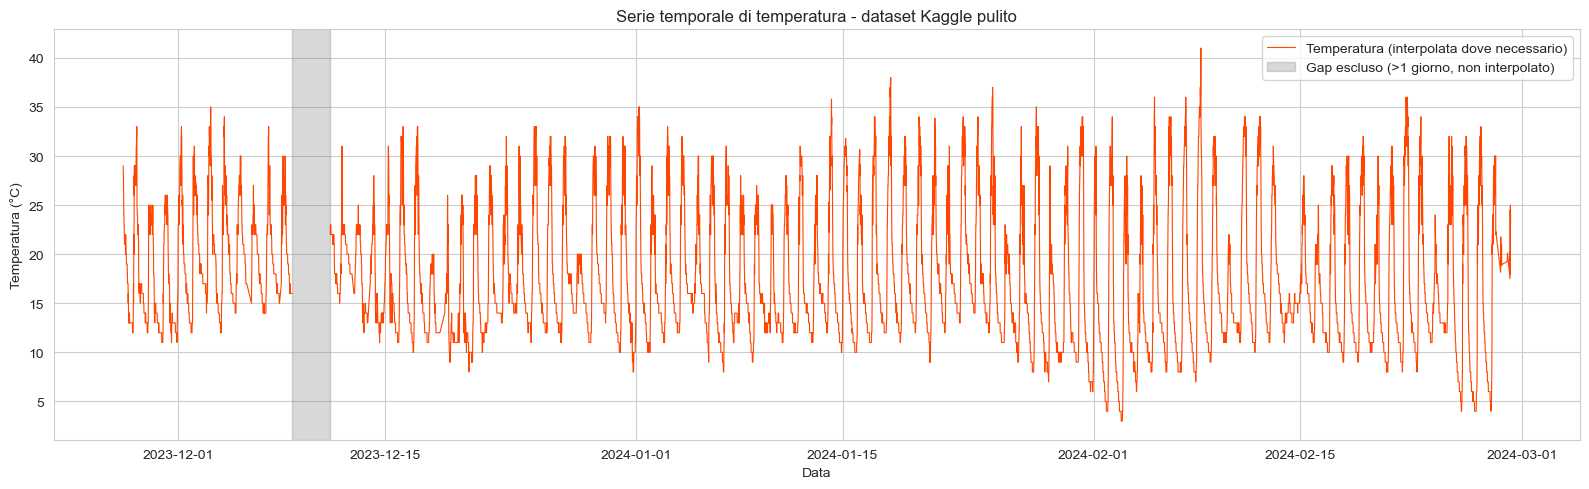

In [46]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df_interpolated.index, df_interpolated["temperature"], 
        color="orangered", linewidth=0.8, label="Temperatura (interpolata dove necessario)")

# Evidenziamo visivamente la zona del gap non interpolato
ax.axvspan(gap_start, gap_end, color="gray", alpha=0.3, label="Gap escluso (>1 giorno, non interpolato)")

ax.set_ylabel("Temperatura (°C)")
ax.set_xlabel("Data")
ax.set_title("Serie temporale di temperatura - dataset Kaggle pulito")
ax.legend()

plt.tight_layout()
plt.show()

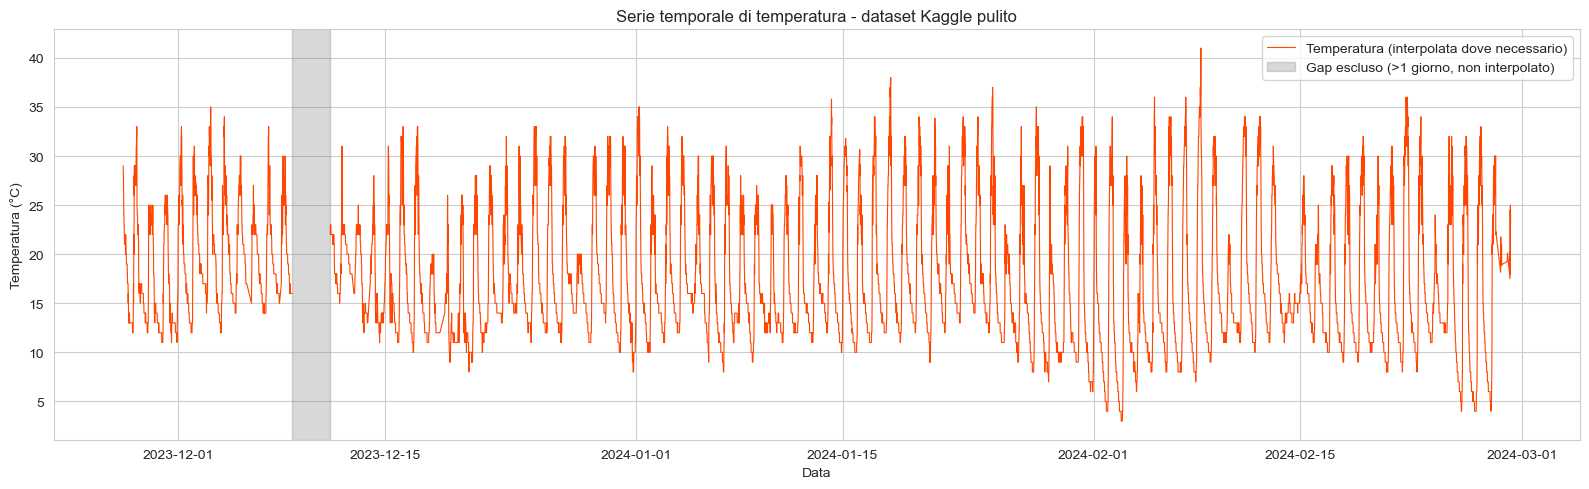

Dataset e grafico salvati.


In [47]:
import os

# Creiamo la cartella data/processed se non esiste già
os.makedirs("../data/processed", exist_ok=True)

# Salviamo il dataset finale pulito e interpolato
df_interpolated.to_csv("../data/processed/iot_agriculture_2024_cleaned.csv")

# Salviamo anche il grafico
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_interpolated.index, df_interpolated["temperature"], 
        color="orangered", linewidth=0.8, label="Temperatura (interpolata dove necessario)")
ax.axvspan(gap_start, gap_end, color="gray", alpha=0.3, label="Gap escluso (>1 giorno, non interpolato)")
ax.set_ylabel("Temperatura (°C)")
ax.set_xlabel("Data")
ax.set_title("Serie temporale di temperatura - dataset Kaggle pulito")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/kaggle_temperature_cleaned.png", dpi=150, bbox_inches="tight")
plt.show()

print("Dataset e grafico salvati.")

In [48]:
len(df_interpolated)

27066